### Vẽ Biểu đồ cho phần b, c 

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

spmf_df = pd.read_csv("./data_graph/apriori_close_stats.csv")
group_df = pd.read_csv("./data_graph/benchmark_results.csv")

In [78]:
group_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Dataset         20 non-null     str    
 1   Minsup          20 non-null     float64
 2   Time_Seconds    20 non-null     float64
 3   Memory_MB       20 non-null     float64
 4   Itemsets_Count  20 non-null     int64  
dtypes: float64(3), int64(1), str(1)
memory usage: 932.0 bytes


In [79]:
# ===== 2. Chuẩn hóa dữ liệu =====
# SPMF: đổi "60 ms" -> 60
spmf_df["time_run_ms"] = spmf_df["time_run"].astype(str).str.replace("ms", "", regex=False).str.strip().astype(float)
spmf_df["source"] = "SPMF"
spmf_df = spmf_df.rename(columns={"dataset": "dataset", "Minsup": "minsup"})
spmf_df = spmf_df[["dataset", "minsup", "time_run_ms", "source", "frequent itemsets counts"]]

# Group: đổi seconds -> ms
group_df["time_run_ms"] = group_df["Time_Seconds"] * 1000
group_df["source"] = "Group"
group_df = group_df.rename(columns={"Dataset": "dataset", "Minsup": "minsup"})
group_df = group_df[["dataset", "minsup", "time_run_ms", "source", "Itemsets_Count"]]


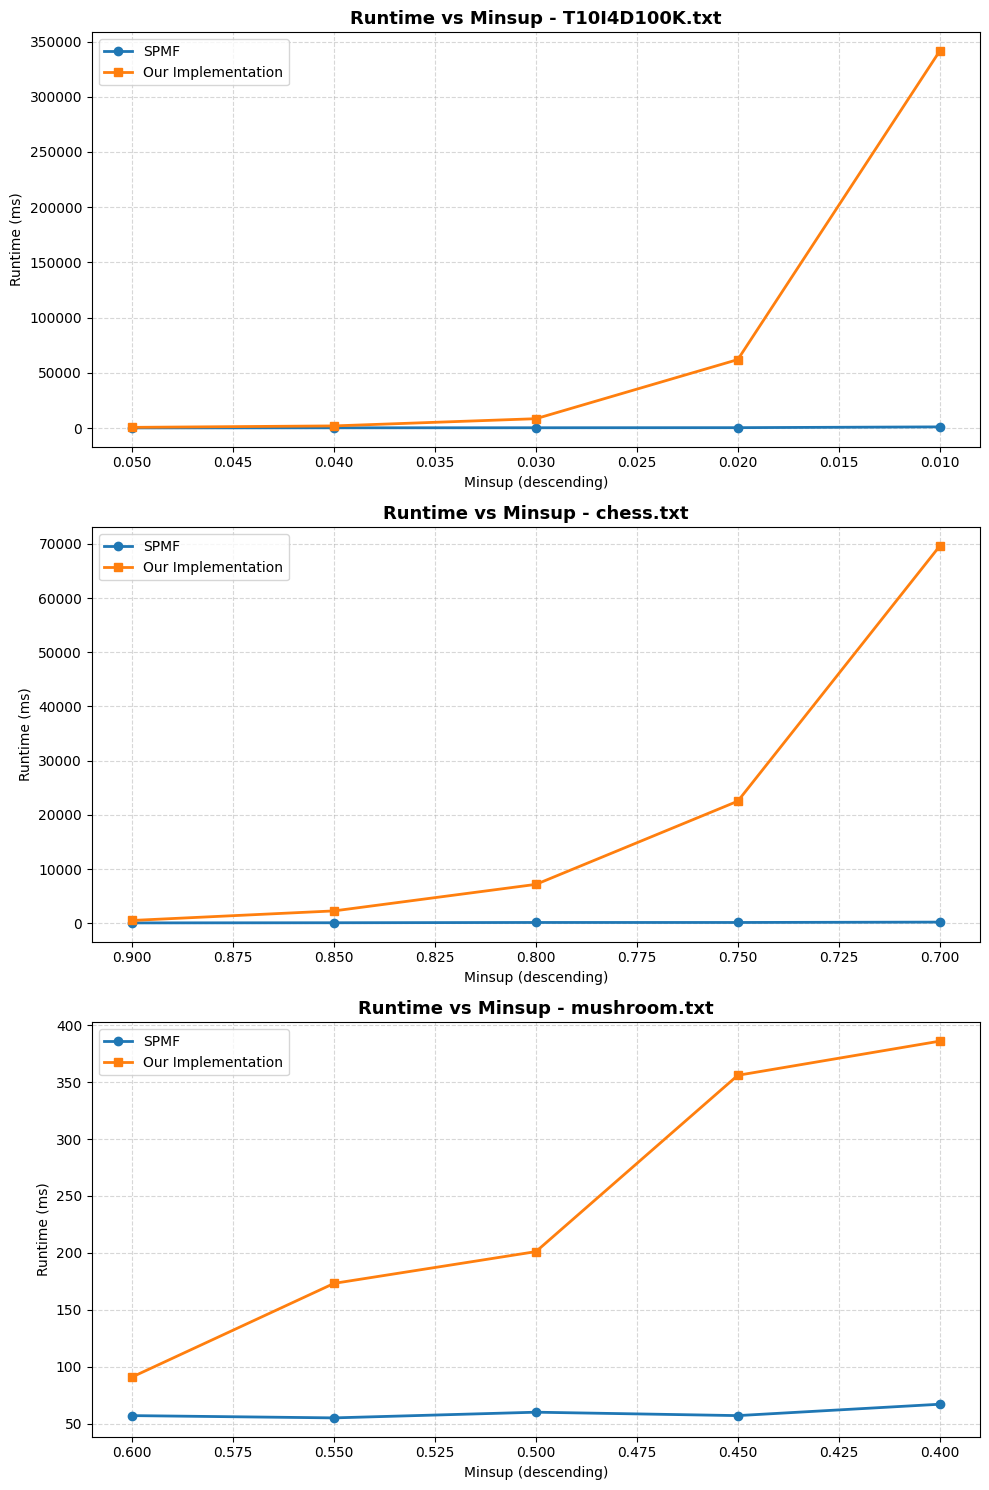

In [80]:


# ===== 3. Gộp dữ liệu =====
merged_df = pd.concat([spmf_df, group_df], ignore_index=True)

# Chỉ giữ các dataset có ít nhất 5 mức minsup khác nhau
valid_datasets = (
    merged_df.groupby("dataset")["minsup"]
    .nunique()
    .reset_index()
)
valid_datasets = valid_datasets[valid_datasets["minsup"] >= 5]["dataset"].tolist()

plot_df = merged_df[merged_df["dataset"].isin(valid_datasets)].copy()

# ===== 4. Vẽ biểu đồ =====
datasets = sorted(plot_df["dataset"].unique())
n = len(datasets)

fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n))

if n == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    data_ds = plot_df[plot_df["dataset"] == dataset].copy()

    spmf_part = data_ds[data_ds["source"] == "SPMF"].sort_values("minsup", ascending=False)
    group_part = data_ds[data_ds["source"] == "Group"].sort_values("minsup", ascending=False)

    ax.plot(
        spmf_part["minsup"],
        spmf_part["time_run_ms"],
        marker="o",
        linewidth=2,
        label="SPMF"
    )

    ax.plot(
        group_part["minsup"],
        group_part["time_run_ms"],
        marker="s",
        linewidth=2,
        label="Our Implementation"
    )

    # ax.set_yscale("log") # Nếu runtime chênh lệch lớn, có thể dùng log scale để dễ nhìn hơn
    ax.set_title(f"Runtime vs Minsup - {dataset}", fontsize=13, weight="bold")
    ax.set_xlabel("Minsup (descending)")
    ax.set_ylabel("Runtime (ms)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

    # Đảo trục X để minsup giảm dần từ trái sang phải
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

In [67]:
plot_df.info()

<class 'pandas.DataFrame'>
Index: 30 entries, 0 to 34
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dataset      30 non-null     str    
 1   minsup       30 non-null     float64
 2   time_run_ms  30 non-null     float64
 3   source       30 non-null     str    
dtypes: float64(2), str(2)
memory usage: 1.2 KB


In [70]:
# ===== 6. Vẽ thêm biểu đồ retail theo dataset/version =====
retail_order = ["retail_10.txt", "retail_25.txt", "retail_50.txt", "retail_75.txt", "retail.txt"]

# Lọc dữ liệu retail từ SPMF
spmf_retail = spmf_df[spmf_df["dataset"].isin(retail_order)].copy()

# Lọc dữ liệu retail từ Group
group_retail = group_df[
    (group_df["dataset"].isin(retail_order)) &
    (group_df["minsup"] == 0.05)
].copy()

# Gộp dữ liệu theo đúng thứ tự mong muốn
retail_plot_df = pd.DataFrame({"dataset": retail_order})

spmf_retail = spmf_retail.groupby("dataset", as_index=False)["time_run_ms"].mean()
spmf_retail = spmf_retail.rename(columns={"time_run_ms": "SPMF"})

group_retail = group_retail.groupby("dataset", as_index=False)["time_run_ms"].mean()
group_retail = group_retail.rename(columns={"time_run_ms": "Group"})

retail_plot_df = retail_plot_df.merge(spmf_retail, on="dataset", how="left")
retail_plot_df = retail_plot_df.merge(group_retail, on="dataset", how="left")


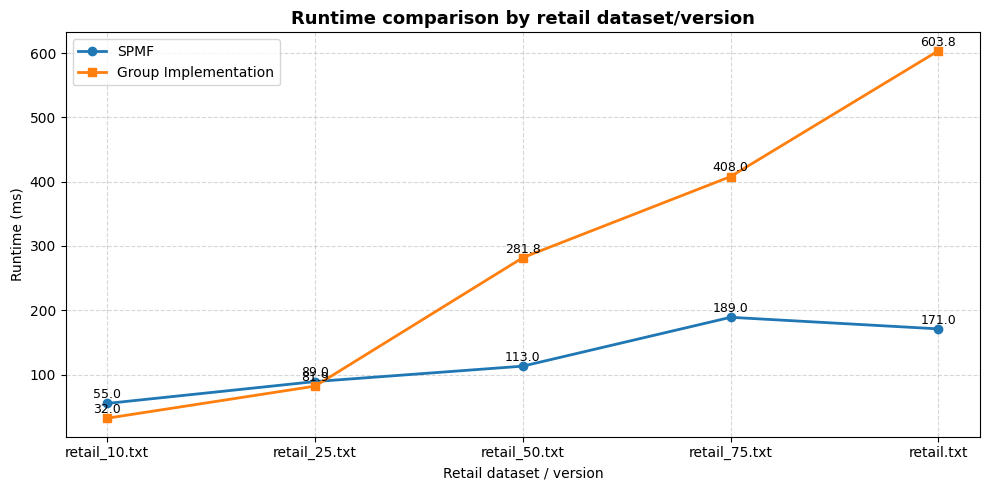

In [71]:

# Vẽ biểu đồ retail
plt.figure(figsize=(10, 5))

plt.plot(
    retail_plot_df["dataset"],
    retail_plot_df["SPMF"],
    marker="o",
    linewidth=2,
    label="SPMF"
)

plt.plot(
    retail_plot_df["dataset"],
    retail_plot_df["Group"],
    marker="s",
    linewidth=2,
    label="Group Implementation"
)

# Hiển thị giá trị trên từng điểm
for x, y in zip(retail_plot_df["dataset"], retail_plot_df["SPMF"]):
    plt.text(x, y + 8, f"{y:.1f}", ha="center", fontsize=9)

for x, y in zip(retail_plot_df["dataset"], retail_plot_df["Group"]):
    plt.text(x, y + 8, f"{y:.1f}", ha="center", fontsize=9)

plt.title("Runtime comparison by retail dataset/version", fontsize=13, weight="bold")
plt.xlabel("Retail dataset / version")
plt.ylabel("Runtime (ms)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
print("SPMF columns:", spmf_df.columns.tolist())
print("GROUP columns:", group_df.columns.tolist())

SPMF columns: ['dataset', 'minsup', 'time_run_ms', 'source', 'frequent itemsets counts']
GROUP columns: ['dataset', 'minsup', 'time_run_ms', 'source', 'Itemsets_Count']


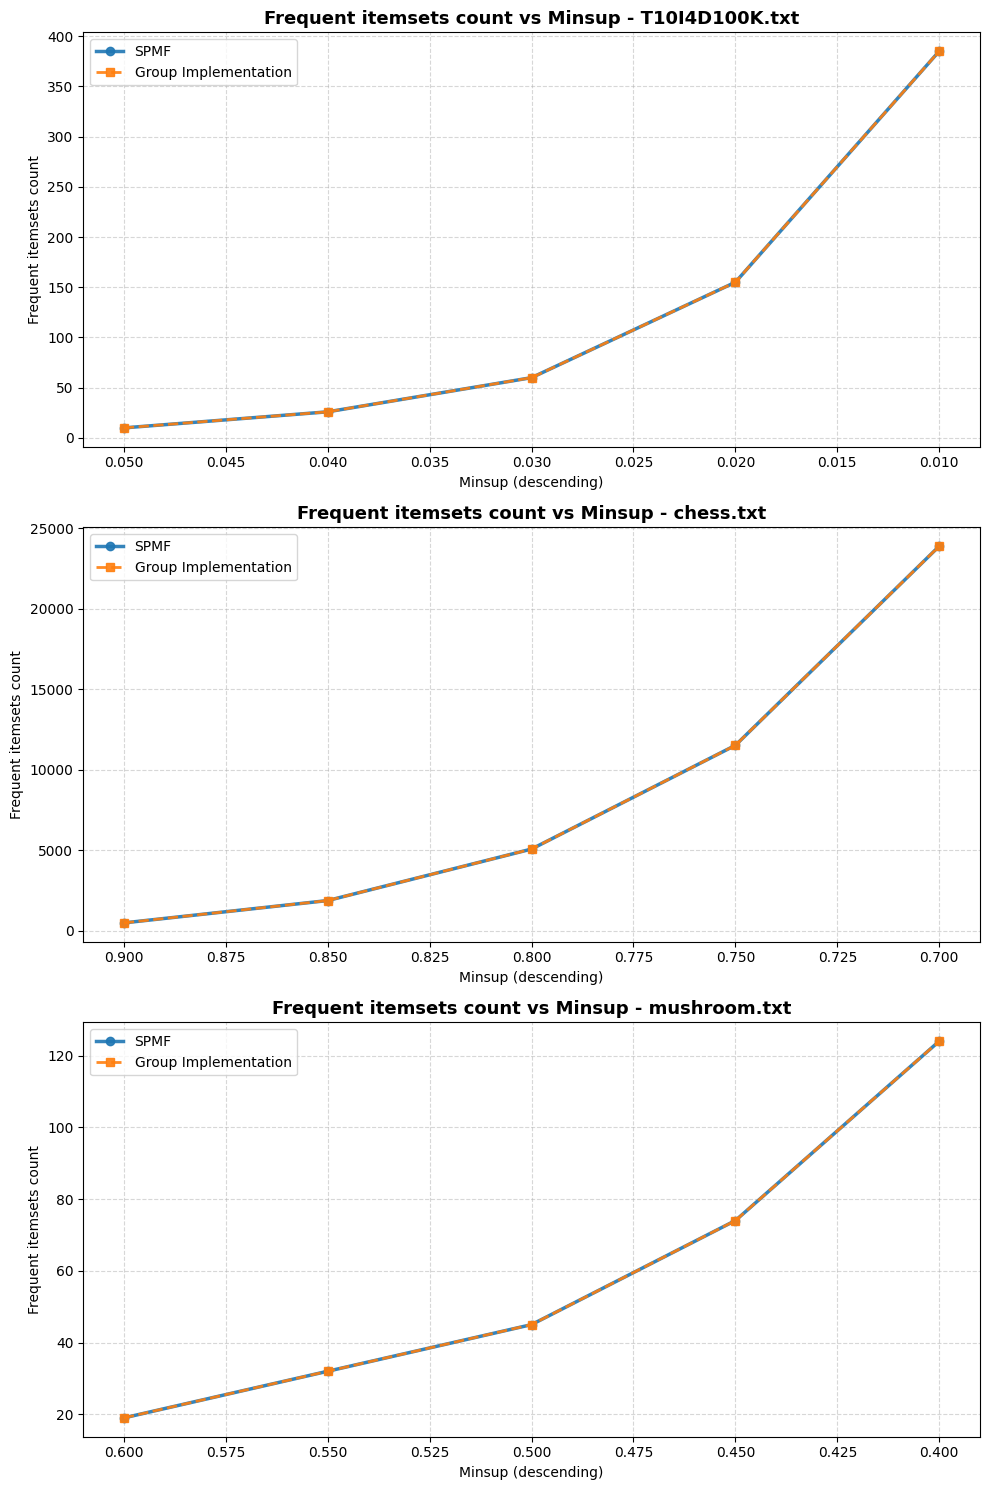

In [83]:
# ===== Vẽ đồ thị số lượng frequent itemsets theo minsup =====

spmf_itemset = spmf_df.copy()
group_itemset = group_df.copy()

spmf_itemset = spmf_itemset.rename(columns={"frequent itemsets counts": "itemsets_count"})
group_itemset = group_itemset.rename(columns={"Itemsets_Count": "itemsets_count"})

exclude_retail = ["retail_10.txt", "retail_25.txt", "retail_50.txt", "retail_75.txt", "retail.txt"]

spmf_itemset = spmf_itemset[~spmf_itemset["dataset"].isin(exclude_retail)].copy()
group_itemset = group_itemset[~group_itemset["dataset"].isin(exclude_retail)].copy()

spmf_itemset["source"] = "SPMF"
group_itemset["source"] = "Group"

plot_itemset_df = pd.concat([
    spmf_itemset[["dataset", "minsup", "itemsets_count", "source"]],
    group_itemset[["dataset", "minsup", "itemsets_count", "source"]]
], ignore_index=True)

datasets = sorted(plot_itemset_df["dataset"].unique())
n = len(datasets)

fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n))

if n == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    data_ds = plot_itemset_df[plot_itemset_df["dataset"] == dataset].copy()

    spmf_part = data_ds[data_ds["source"] == "SPMF"].sort_values("minsup", ascending=False)
    group_part = data_ds[data_ds["source"] == "Group"].sort_values("minsup", ascending=False)

    ax.plot(
        spmf_part["minsup"],
        spmf_part["itemsets_count"],
        marker="o",
        linestyle="-",
        linewidth=2.5,
        alpha=0.9,
        label="SPMF",
        zorder=2
    )

    ax.plot(
        group_part["minsup"],
        group_part["itemsets_count"],
        marker="s",
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label="Group Implementation",
        zorder=3
    )

    ax.set_title(f"Frequent itemsets count vs Minsup - {dataset}", fontsize=13, weight="bold")
    ax.set_xlabel("Minsup (descending)")
    ax.set_ylabel("Frequent itemsets count")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

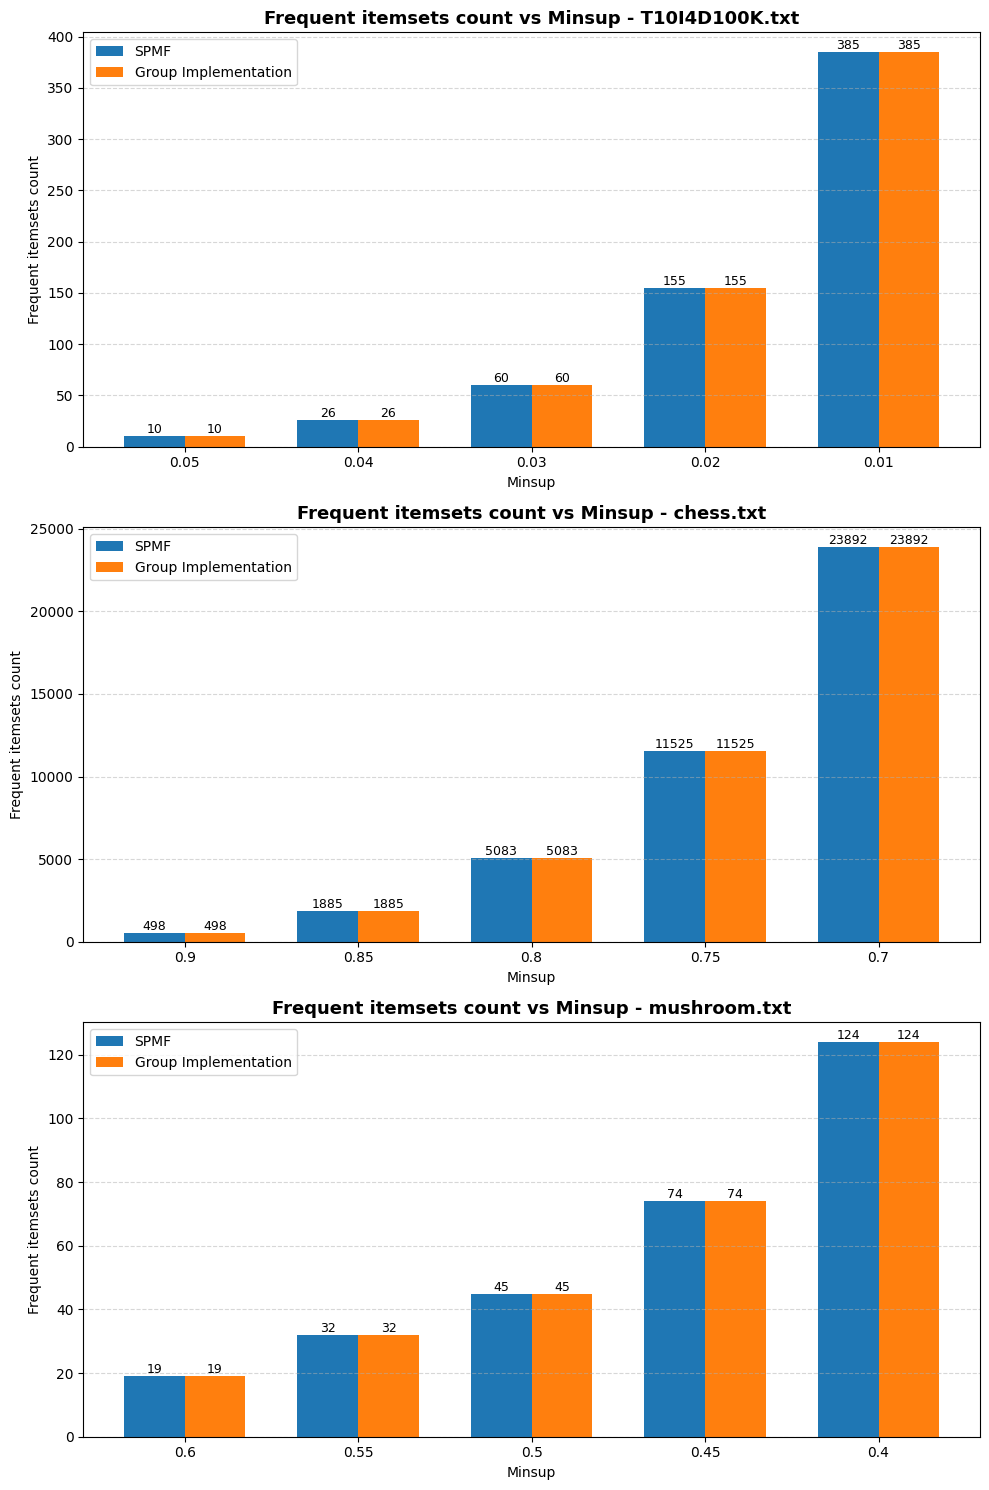

In [85]:
import numpy as np
import matplotlib.pyplot as plt

spmf_itemset = spmf_df.copy()
group_itemset = group_df.copy()

spmf_itemset = spmf_itemset.rename(columns={"frequent itemsets counts": "itemsets_count"})
group_itemset = group_itemset.rename(columns={"Itemsets_Count": "itemsets_count"})

exclude_retail = ["retail_10.txt", "retail_25.txt", "retail_50.txt", "retail_75.txt", "retail.txt"]

spmf_itemset = spmf_itemset[~spmf_itemset["dataset"].isin(exclude_retail)].copy()
group_itemset = group_itemset[~group_itemset["dataset"].isin(exclude_retail)].copy()

datasets = sorted(spmf_itemset["dataset"].unique())
n = len(datasets)

fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n))

if n == 1:
    axes = [axes]

bar_width = 0.35

for ax, dataset in zip(axes, datasets):
    spmf_part = spmf_itemset[spmf_itemset["dataset"] == dataset].sort_values("minsup", ascending=False)
    group_part = group_itemset[group_itemset["dataset"] == dataset].sort_values("minsup", ascending=False)

    minsup_labels = spmf_part["minsup"].astype(str).tolist()
    x = np.arange(len(minsup_labels))

    bars1 = ax.bar(x - bar_width / 2, spmf_part["itemsets_count"], width=bar_width, label="SPMF")
    bars2 = ax.bar(x + bar_width / 2, group_part["itemsets_count"], width=bar_width, label="Group Implementation")

    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{int(h)}", ha="center", va="bottom", fontsize=9)

    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{int(h)}", ha="center", va="bottom", fontsize=9)

    ax.set_title(f"Frequent itemsets count vs Minsup - {dataset}", fontsize=13, weight="bold")
    ax.set_xlabel("Minsup")
    ax.set_ylabel("Frequent itemsets count")
    ax.set_xticks(x)
    ax.set_xticklabels(minsup_labels)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()